- Nama: Fahma Zuaf Zarir
- NIM: 23611054
- Kelas: A

# Proses Clustering

In [2]:
# Import library
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.cluster import DBSCAN
import sklearn.utils
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_samples, silhouette_score
from yellowbrick.cluster import KElbowVisualizer
%matplotlib inline

## Load Dataset

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/FahmaZuaf/Proses_Clustering/main/Mall_Customers.csv', sep=',')
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## K-Means Clustering

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


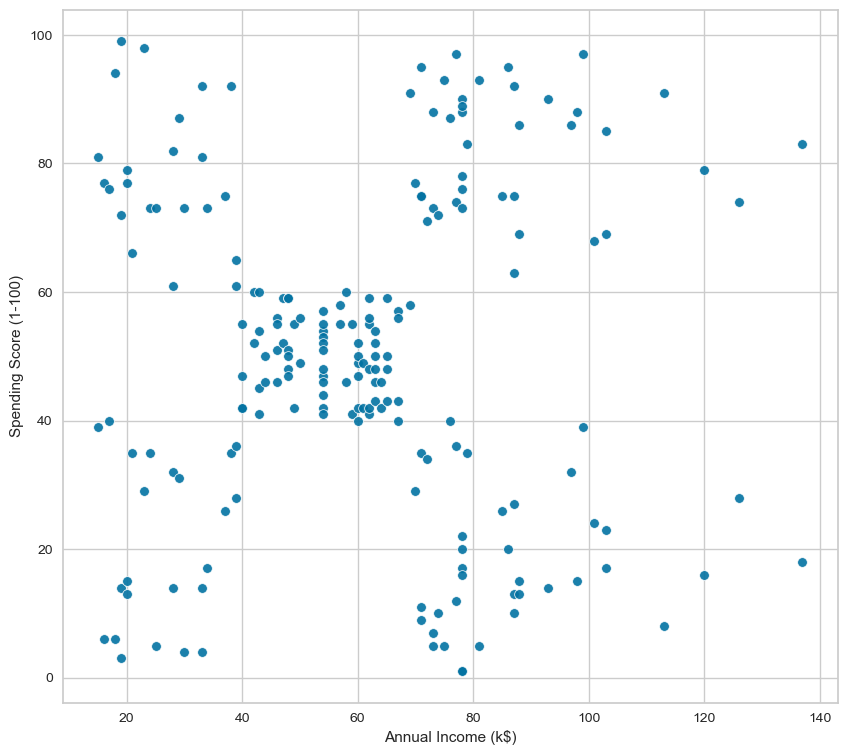

In [5]:
plt.figure(figsize=(10, 9))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', data=df, alpha=0.9)
plt.show()

In [6]:
data_x = df.iloc[:, 3:5]
data_x.head()
x_array =  np.array(data_x)
print(x_array)

[[ 15  39]
 [ 15  81]
 [ 16   6]
 [ 16  77]
 [ 17  40]
 [ 17  76]
 [ 18   6]
 [ 18  94]
 [ 19   3]
 [ 19  72]
 [ 19  14]
 [ 19  99]
 [ 20  15]
 [ 20  77]
 [ 20  13]
 [ 20  79]
 [ 21  35]
 [ 21  66]
 [ 23  29]
 [ 23  98]
 [ 24  35]
 [ 24  73]
 [ 25   5]
 [ 25  73]
 [ 28  14]
 [ 28  82]
 [ 28  32]
 [ 28  61]
 [ 29  31]
 [ 29  87]
 [ 30   4]
 [ 30  73]
 [ 33   4]
 [ 33  92]
 [ 33  14]
 [ 33  81]
 [ 34  17]
 [ 34  73]
 [ 37  26]
 [ 37  75]
 [ 38  35]
 [ 38  92]
 [ 39  36]
 [ 39  61]
 [ 39  28]
 [ 39  65]
 [ 40  55]
 [ 40  47]
 [ 40  42]
 [ 40  42]
 [ 42  52]
 [ 42  60]
 [ 43  54]
 [ 43  60]
 [ 43  45]
 [ 43  41]
 [ 44  50]
 [ 44  46]
 [ 46  51]
 [ 46  46]
 [ 46  56]
 [ 46  55]
 [ 47  52]
 [ 47  59]
 [ 48  51]
 [ 48  59]
 [ 48  50]
 [ 48  48]
 [ 48  59]
 [ 48  47]
 [ 49  55]
 [ 49  42]
 [ 50  49]
 [ 50  56]
 [ 54  47]
 [ 54  54]
 [ 54  53]
 [ 54  48]
 [ 54  52]
 [ 54  42]
 [ 54  51]
 [ 54  55]
 [ 54  41]
 [ 54  44]
 [ 54  57]
 [ 54  46]
 [ 57  58]
 [ 57  55]
 [ 58  60]
 [ 58  46]
 [ 59  55]

In [7]:
scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x_array)
x_scaled

array([[0.        , 0.3877551 ],
       [0.        , 0.81632653],
       [0.00819672, 0.05102041],
       [0.00819672, 0.7755102 ],
       [0.01639344, 0.39795918],
       [0.01639344, 0.76530612],
       [0.02459016, 0.05102041],
       [0.02459016, 0.94897959],
       [0.03278689, 0.02040816],
       [0.03278689, 0.7244898 ],
       [0.03278689, 0.13265306],
       [0.03278689, 1.        ],
       [0.04098361, 0.14285714],
       [0.04098361, 0.7755102 ],
       [0.04098361, 0.12244898],
       [0.04098361, 0.79591837],
       [0.04918033, 0.34693878],
       [0.04918033, 0.66326531],
       [0.06557377, 0.28571429],
       [0.06557377, 0.98979592],
       [0.07377049, 0.34693878],
       [0.07377049, 0.73469388],
       [0.08196721, 0.04081633],
       [0.08196721, 0.73469388],
       [0.10655738, 0.13265306],
       [0.10655738, 0.82653061],
       [0.10655738, 0.31632653],
       [0.10655738, 0.6122449 ],
       [0.1147541 , 0.30612245],
       [0.1147541 , 0.87755102],
       [0.

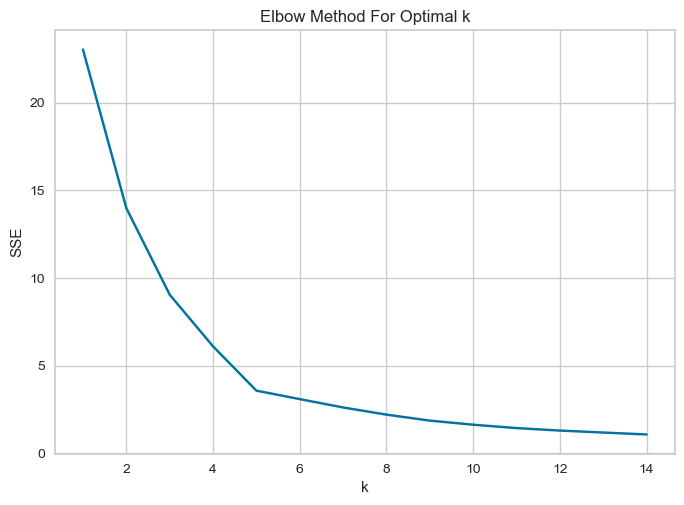

In [8]:
Sum_of_squared_distances =[]
K = range(1,15)
for k in K:
    km =KMeans(n_clusters =k)
    km =km.fit(x_scaled)
    Sum_of_squared_distances.append(km.inertia_)
    
plt.plot(K, Sum_of_squared_distances, 'bx-')
plt.xlabel('k')
plt.ylabel('SSE')
plt.title('Elbow Method For Optimal k')
plt.show()

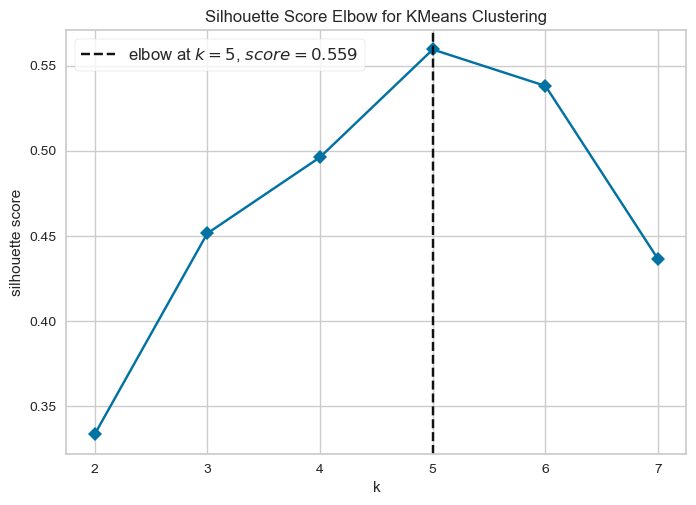

<Axes: title={'center': 'Silhouette Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='silhouette score'>

In [9]:
model = KMeans(random_state=123) 
visualizer = KElbowVisualizer(model, k=(2,8), metric='silhouette', timings=False)

visualizer.fit(x_scaled)    
visualizer.poof()

In [10]:
numerics = df[['Annual Income (k$)','Spending Score (1-100)']]
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
for i in numerics:
        scaler.fit(df[[i]])
        df[i] = scaler.transform(df[[i]])
km = KMeans(n_clusters=5)
y_predicted = km.fit_predict(df[['Annual Income (k$)', 'Spending Score (1-100)']])
y_predicted

array([4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3,
       4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 1,
       4, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 0, 2, 1, 2, 0, 2, 0, 2,
       1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2])

In [11]:
df["Cluster"] = y_predicted
df.head(10)

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,0.000000,0.387755,4
1,2,Male,21,0.000000,0.816327,3
2,3,Female,20,0.008197,0.051020,4
3,4,Female,23,0.008197,0.775510,3
4,5,Female,31,0.016393,0.397959,4
5,6,Female,22,0.016393,0.765306,3
6,7,Female,35,0.024590,0.051020,4
7,8,Female,23,0.024590,0.948980,3
8,9,Male,64,0.032787,0.020408,4
9,10,Female,30,0.032787,0.724490,3


In [12]:
km.cluster_centers_

array([[0.6       , 0.16443149],
       [0.33029751, 0.49508692],
       [0.58638083, 0.82783883],
       [0.08792846, 0.79962894],
       [0.09265859, 0.20319432]])

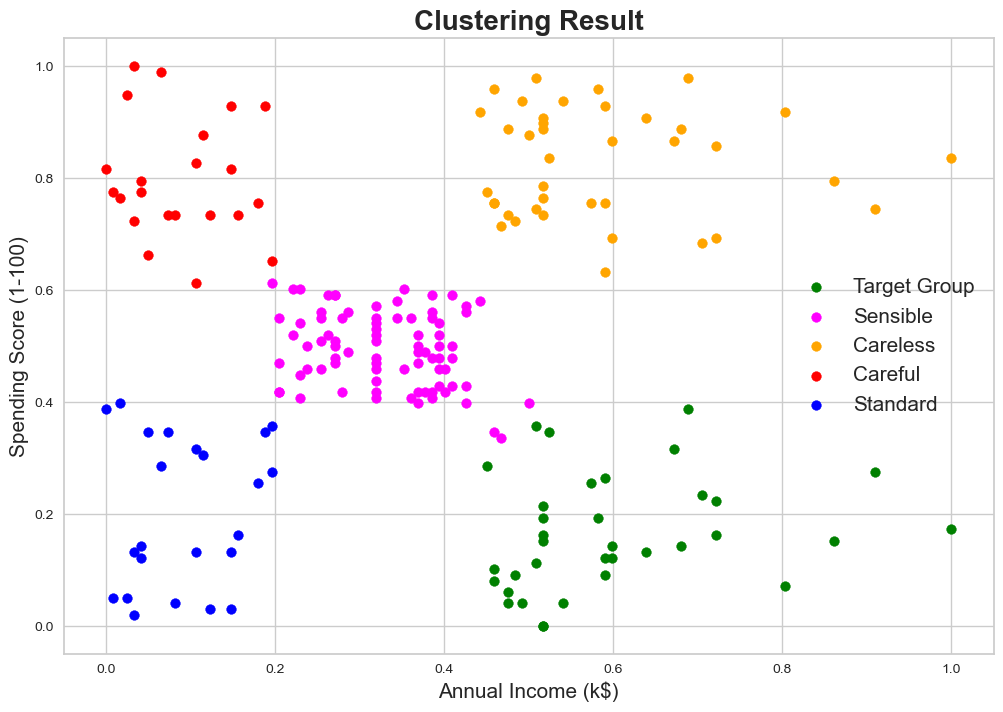

In [13]:
plt.figure(figsize=(12,8))
df1 = df[df.Cluster==0]
df2 = df[df.Cluster==1]
df3 = df[df.Cluster==2]
df4 = df[df.Cluster==3]
df5 = df[df.Cluster==4]
plt.scatter(df1['Annual Income (k$)'],df1['Spending Score (1-100)'],color='green', label='Target Group')
plt.scatter(df2['Annual Income (k$)'],df2['Spending Score (1-100)'],color='magenta', label='Sensible')
plt.scatter(df3['Annual Income (k$)'],df3['Spending Score (1-100)'],color='orange', label='Careless')
plt.scatter(df4['Annual Income (k$)'],df4['Spending Score (1-100)'],color='red', label='Careful')
plt.scatter(df5['Annual Income (k$)'],df5['Spending Score (1-100)'],color='blue', label='Standard')
plt.title('Clustering Result', fontweight='bold',fontsize=20)
plt.xlabel('Annual Income (k$)',fontsize=15)
plt.ylabel('Spending Score (1-100)',fontsize=15)
plt.legend(fontsize=15)
plt.grid(True)
plt.show()

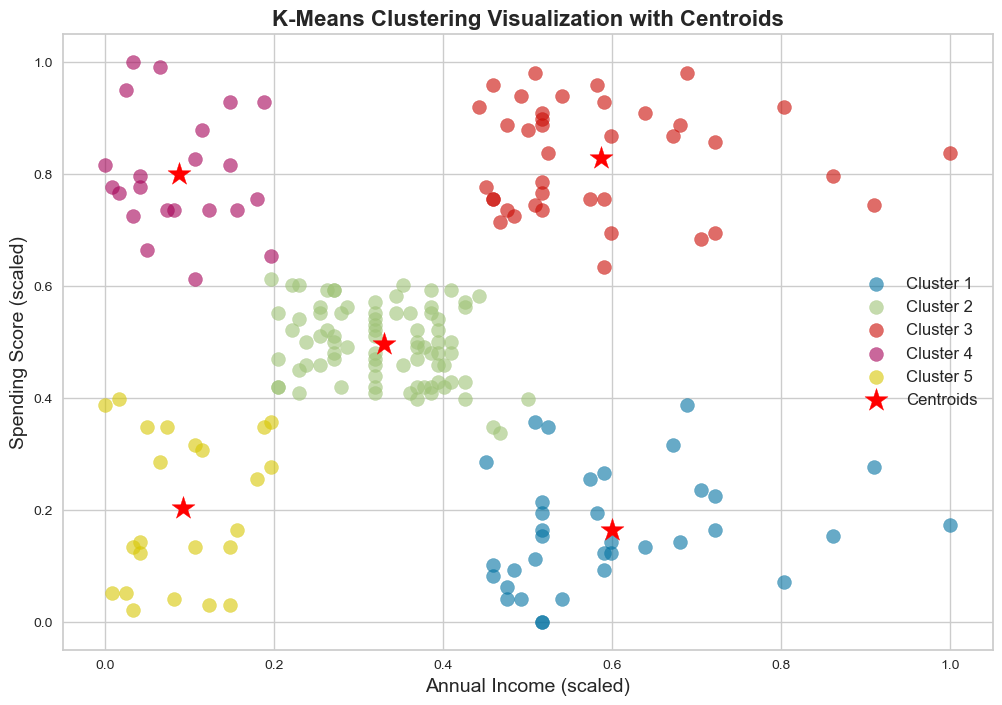

In [14]:
# Visualize the K-Means clustering with centroids
plt.figure(figsize=(12, 8))

# Scatter plot for each cluster
for i in range(km.n_clusters):
    plt.scatter(x_scaled[y_predicted == i, 0], x_scaled[y_predicted == i, 1], 
                label=f'Cluster {i+1}', s=100, alpha=0.6)

# Plot the centroids
plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1], 
            s=300, c='red', marker='*', label='Centroids')

# Add title and labels
plt.title('K-Means Clustering Visualization with Centroids', fontsize=16, fontweight='bold')
plt.xlabel('Annual Income (scaled)', fontsize=14)
plt.ylabel('Spending Score (scaled)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

## Hierarchical Clustering

Hierarchical clustering melibatkan pembuatan klaster yang memiliki urutan yang telah ditentukan dari atas ke bawah. Ada dua jenis pengelompokan hierarkis, yaitu Agglomerative dan Divisive.

Hierarchical clustering dimulai dengan memperlakukan setiap observasi sebagai klaster terpisah. Kemudian, pengelompokan tersebut berulang kali menjalankan langkah-langkah berikut:

- Identifikasi dua klaster yang paling dekat satu sama lain
- Gabungkan dua klaster yang paling mirip

### Load dataset

In [15]:
df_hc = pd.read_csv('https://raw.githubusercontent.com/FahmaZuaf/Proses_Clustering/main/Mall_Customers.csv', sep=',')
df_hc.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### Checking Distribution of Annual Income

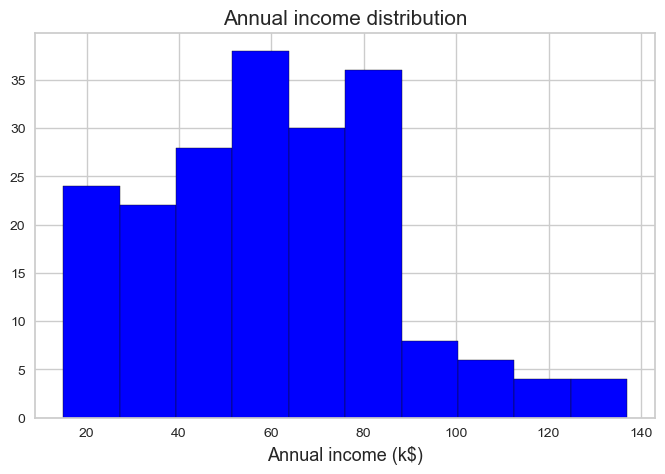

In [16]:
plt.figure(figsize=(8,5))
plt.title("Annual income distribution",fontsize=15)
plt.xlabel ("Annual income (k$)",fontsize=13)
plt.grid(True)
plt.hist(df_hc['Annual Income (k$)'],color='blue',edgecolor='k')
plt.show()

### Checking the Distribution of Spending Score

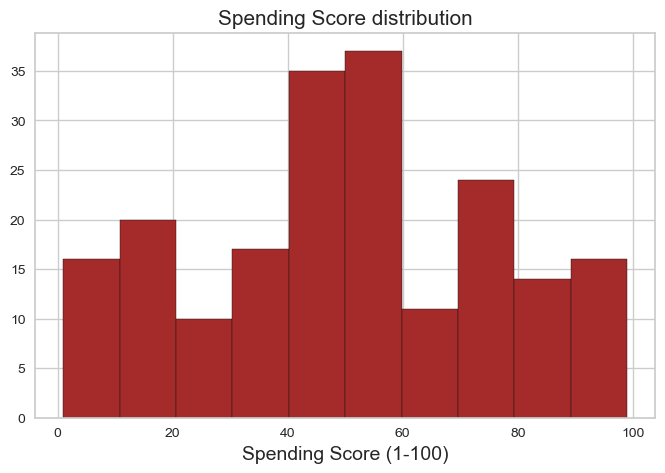

In [17]:
plt.figure(figsize=(8,5))
plt.title("Spending Score distribution",fontsize=15)
plt.xlabel ("Spending Score (1-100)",fontsize=14)
plt.grid(True)
plt.hist(df_hc['Spending Score (1-100)'],color='brown',edgecolor='k')
plt.show()

### Visualizing Annual Income and Spending Score using Scatter Plot

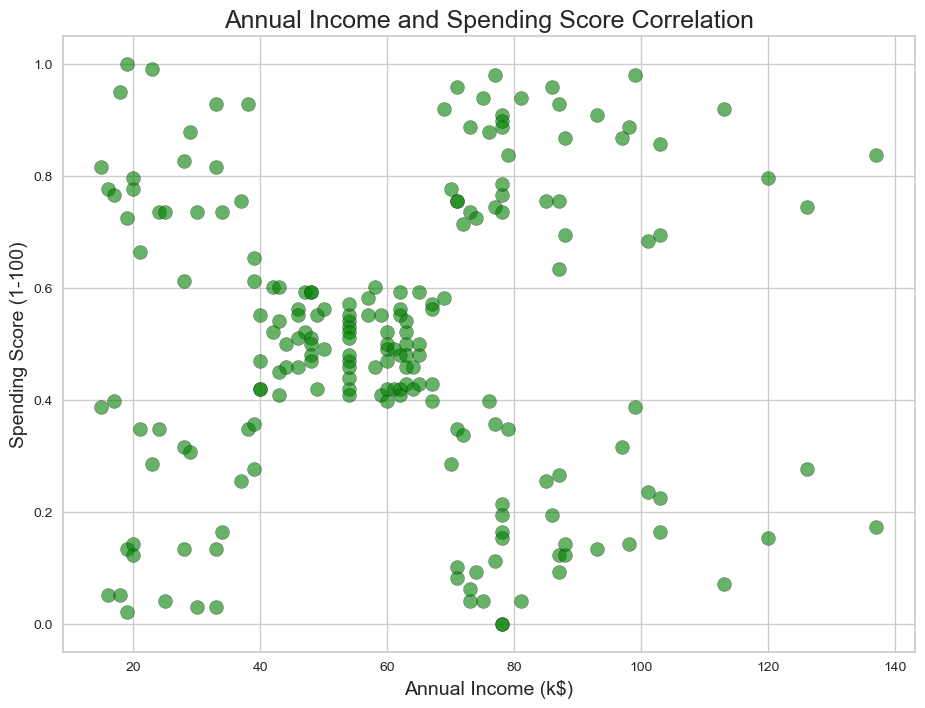

In [18]:
plt.figure(figsize=(11,8))
plt.title("Annual Income and Spending Score Correlation",fontsize=18)
plt.xlabel ("Annual Income (k$)",fontsize=14)
plt.ylabel ("Spending Score (1-100)",fontsize=14)
plt.grid(True)
plt.scatter(df_hc['Annual Income (k$)'],df['Spending Score (1-100)'],color='green',edgecolor='k',alpha=0.6, s=100)
plt.show()

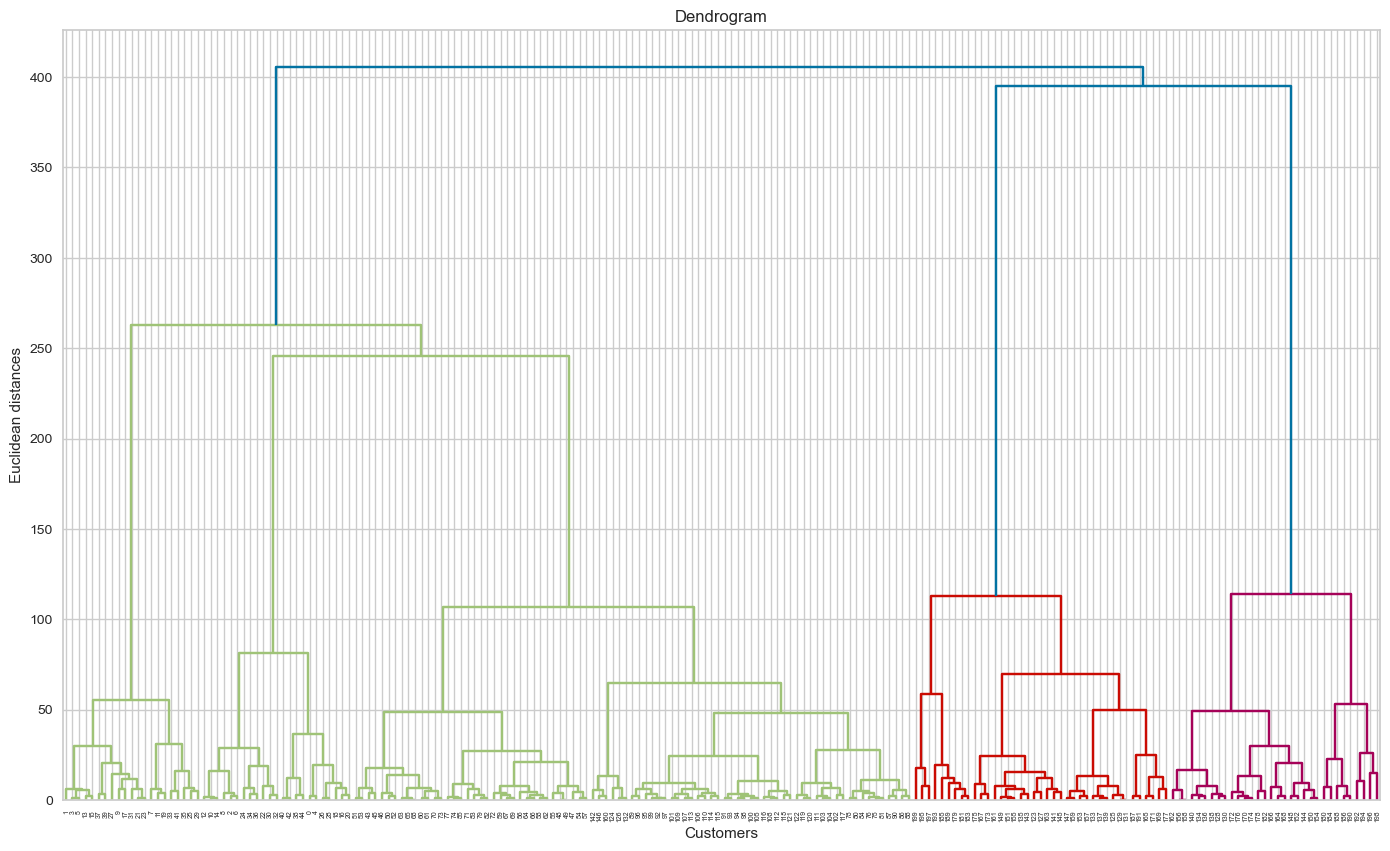

In [19]:
X = df_hc.iloc[:,[3,4]].values
import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster import hierarchy
plt.figure(figsize=(17,10))
plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean distances')
#plt.grid(True)
dendrogram = sch.dendrogram(sch.linkage(X, method = 'ward'))
plt.show()

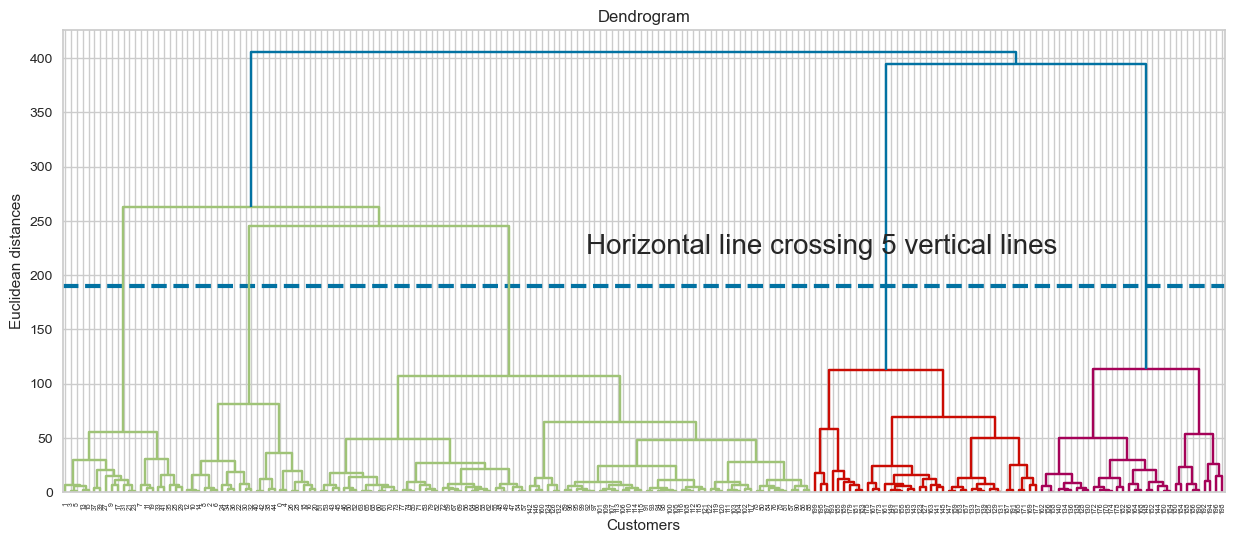

In [20]:
plt.figure(figsize=(15,6))
plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean distances')
plt.hlines(y=190,xmin=0,xmax=2000,lw=3,linestyles='--')
plt.text(x=900,y=220,s='Horizontal line crossing 5 vertical lines',fontsize=20)
#plt.grid(True)
dendrogram = sch.dendrogram(sch.linkage(X, method = 'ward'))
plt.show()

Dendrogram adalah diagram pohon yang sering digunakan untuk menggambarkan susunan klaster yang dihasilkan oleh Hierarchical Clustering. Subset data yang serupa dibuat dalam struktur seperti pohon di mana simpul akar sesuai dengan seluruh data dan cabang dibuat dari simpul akar untuk membentuk beberapa klaster. Jumlah klaster yang optimal sama dengan jumlah garis vertikal yang melewati garis horizontal.

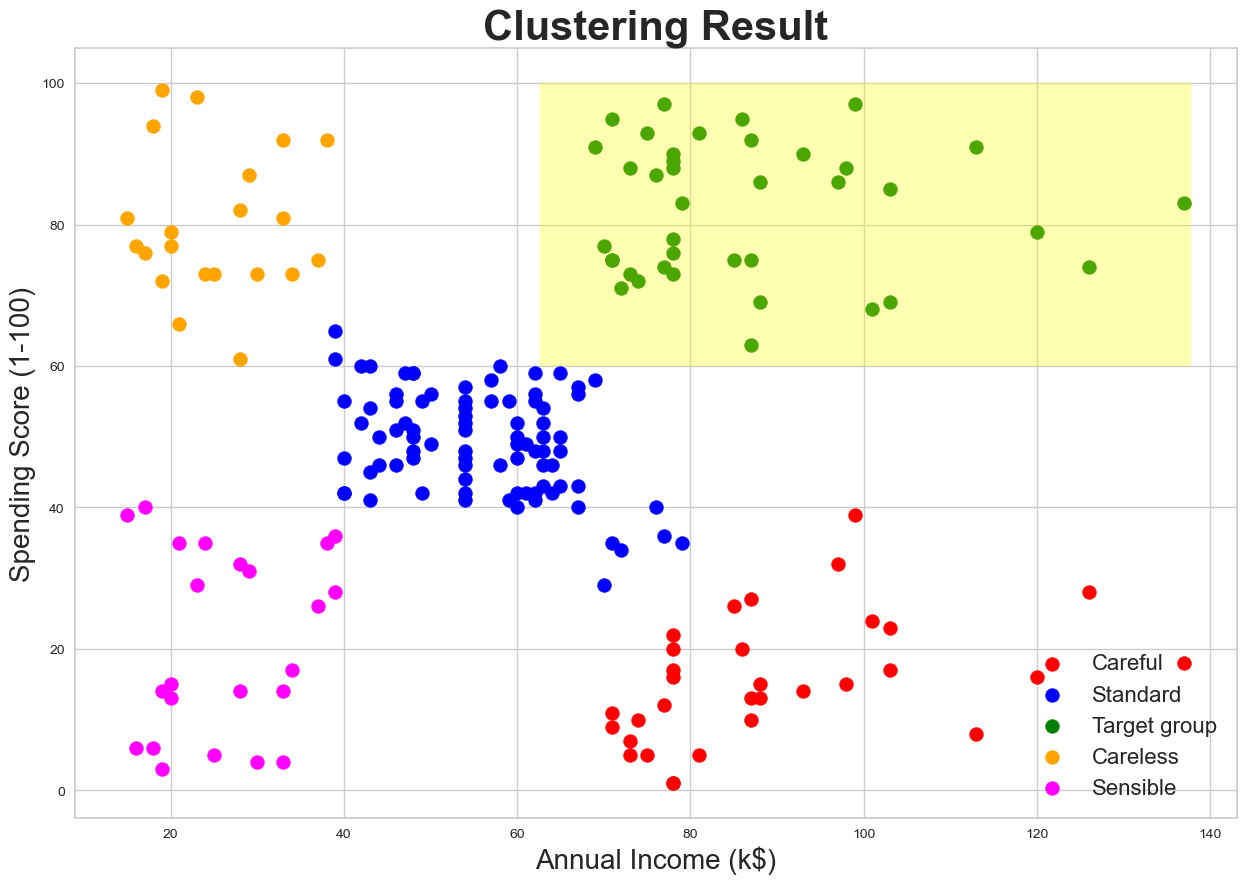

In [21]:
from sklearn.cluster import AgglomerativeClustering
hc = AgglomerativeClustering(n_clusters = 5, affinity = 'euclidean', linkage = 'ward')
y_hc = hc.fit_predict(X)
plt.figure(figsize=(15,10))
plt.scatter(X[y_hc == 0, 0], X[y_hc == 0, 1], s = 100, c = 'red', label = 'Careful')
plt.scatter(X[y_hc == 1, 0], X[y_hc == 1, 1], s = 100, c = 'blue', label = 'Standard')
plt.scatter(X[y_hc == 2, 0], X[y_hc == 2, 1], s = 100, c = 'green', label = 'Target group')
plt.scatter(X[y_hc == 3, 0], X[y_hc == 3, 1], s = 100, c = 'orange', label = 'Careless')
plt.scatter(X[y_hc == 4, 0], X[y_hc == 4, 1], s = 100, c = 'magenta', label = 'Sensible')
plt.title('Clustering Result', fontweight='bold',fontsize=30)
plt.xlabel('Annual Income (k$)',fontsize=20)
plt.ylabel('Spending Score (1-100)',fontsize=20)
plt.legend(fontsize=16)
plt.grid(True)
plt.axhspan(ymin=60,ymax=100,xmin=0.4,xmax=0.96,alpha=0.3,color='yellow')
plt.show()

## DBSCAN

### Import Dataset

In [22]:
df_dbscan = pd.read_csv('https://raw.githubusercontent.com/FahmaZuaf/Proses_Clustering/main/Mall_Customers.csv', sep=',')
df_dbscan.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### Buat objek DBSCAN dan fit datanya kemudian didefinisikan `eps` = 0.4 dan ``min_samples`` = 5

In [23]:
Clus_dataSet = df_dbscan[['Annual Income (k$)','Spending Score (1-100)']]
Clus_dataSet = np.nan_to_num(Clus_dataSet)
Clus_dataSet = np.array(Clus_dataSet, dtype=np.float64)
Clus_dataSet = StandardScaler().fit_transform(Clus_dataSet)
# Compute DBSCAN
db = DBSCAN(eps=0.4, min_samples=5).fit(Clus_dataSet)
core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True
labels = db.labels_
df_dbscan['Clus_Db']=labels
realClusterNum=len(set(labels)) - (1 if -1 in labels else 0)
clusterNum = len(set(labels))
# A sample of clusters
print(df_dbscan[['Annual Income (k$)','Spending Score (1-100)']].head())
# Number of Labels
print("number of labels: ", set(labels))

   Annual Income (k$)  Spending Score (1-100)
0                  15                      39
1                  15                      81
2                  16                       6
3                  16                      77
4                  17                      40
number of labels:  {0, 1, 2, 3, -1}


### Visualize the Clusters Determined 

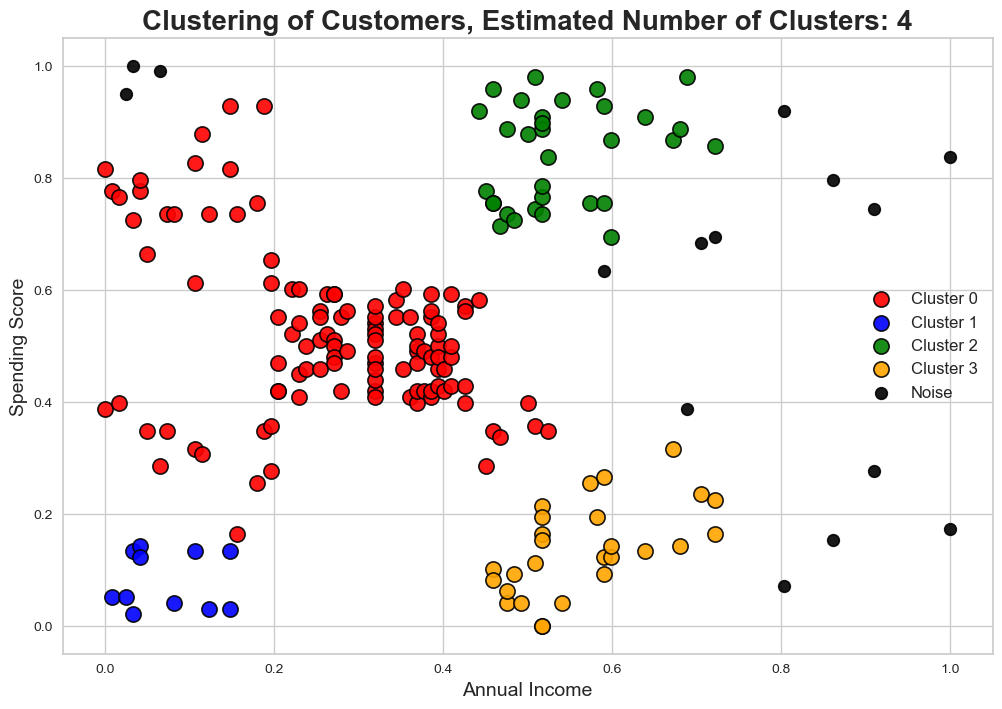

In [24]:
# Visualize the clusters determined
plt.figure(figsize=(12, 8))

# Define a list of distinct colors for clusters
distinct_colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'cyan']

# Scatter plot for each cluster
for cluster in range(realClusterNum):
    plt.scatter(x_scaled[labels == cluster, 0], x_scaled[labels == cluster, 1], 
                label=f'Cluster {cluster}', s=120, alpha=0.9, color=distinct_colors[cluster % len(distinct_colors)], edgecolor='black', linewidth=1.2)

# Plot the noise points
plt.scatter(x_scaled[labels == -1, 0], x_scaled[labels == -1, 1], 
            c='black', label='Noise', s=70, alpha=0.9, edgecolor='black', linewidth=1.2)

# Add title and labels
plt.title('Clustering of Customers, Estimated Number of Clusters: %d' % realClusterNum, fontweight='bold',fontsize=20)
plt.xlabel('Annual Income', fontsize=14)
plt.ylabel('Spending Score', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

In [25]:
for clust_number in set(labels):
    clust_set = df_dbscan[df_dbscan.Clus_Db == clust_number]
    if clust_number != -1:
        print("Cluster "+str(clust_number)+
              ', Avg Annual Income: ' + str(round(np.mean(clust_set['Annual Income (k$)']))) +
              ', Avg Spending Score: ' + str(round(np.mean(clust_set['Spending Score (1-100)']))) +
              ', Count: ' + str(np.count_nonzero(clust_set.index)))

Cluster 0, Avg Annual Income: 48, Avg Spending Score: 52, Count: 114
Cluster 1, Avg Annual Income: 24, Avg Spending Score: 9, Count: 11
Cluster 2, Avg Annual Income: 81, Avg Spending Score: 84, Count: 32
Cluster 3, Avg Annual Income: 84, Avg Spending Score: 14, Count: 27


Dari bagian implementasi DBSCAN ini, kita dapat menyimpulkan jika DBSCAN bekerja dengan sangat baik dalam mendeteksi outlier yang tidak akan mudah dilakukan dengan teknik K-Means atau Hierarchical Clustering. Jika kita juga menerapkan DBSCAN pada kumpulan data dengan kluster berbentuk sembarang, kita akan melihat keberhasilan DBSCAN juga.

# Conclusion

In [27]:
# Menghitung jumlah klaster optimal berdasarkan data
optimal_clusters = len(set(y_predicted)) - (1 if -1 in y_predicted else 0)
print(f"Jumlah klaster optimal: {optimal_clusters}")

# Menghitung rata-rata ukuran klaster
cluster_sizes = df.groupby('Cluster').size()
print("\nUkuran setiap klaster:")
print(cluster_sizes)

# Perkiraan biaya marketing (misalnya, biaya per pelanggan adalah 100)
cost_per_customer = 100
marketing_costs = cluster_sizes * cost_per_customer
print("\nPerkiraan biaya marketing untuk setiap klaster:")
print(marketing_costs)

Jumlah klaster optimal: 5

Ukuran setiap klaster:
Cluster
0    35
1    81
2    39
3    22
4    23
dtype: int64

Perkiraan biaya marketing untuk setiap klaster:
Cluster
0    3500
1    8100
2    3900
3    2200
4    2300
dtype: int64


Cluster paling optimal adalah 5 karena metode seperti **Elbow Method** dan **Silhouette Score** yang digunakan pada K-Means dan Hierarchical Clustering menunjukkan bahwa 5 adalah jumlah cluster yang memberikan keseimbangan terbaik antara jumlah cluster dan variasi dalam data. Metode ini mempertimbangkan distribusi data dan memastikan bahwa cluster yang dihasilkan memiliki kualitas yang baik.

Mengapa tidak menggunakan DBSCAN meskipun menghasilkan 4 cluster:
1. **DBSCAN Sensitif terhadap Parameter**: DBSCAN sangat bergantung pada parameter seperti `eps` dan `min_samples`. Jika parameter ini tidak dipilih dengan tepat, hasil clustering dapat menjadi tidak optimal atau tidak sesuai dengan struktur data.
2. **DBSCAN Tidak Cocok untuk Data dengan Kepadatan Berbeda**: DBSCAN bekerja dengan baik untuk data dengan kepadatan yang seragam. Namun, jika dataset memiliki cluster dengan kepadatan yang sangat bervariasi, DBSCAN mungkin tidak dapat mendeteksi cluster dengan benar.
3. **Outlier Handling**: DBSCAN mendeteksi outlier sebagai noise, yang berguna dalam beberapa kasus. Namun, jika tujuan utama adalah segmentasi pelanggan tanpa fokus pada outlier, metode seperti K-Means atau Hierarchical Clustering lebih cocok.
4. **Visualisasi dan Interpretasi**: K-Means dan Hierarchical Clustering lebih mudah diinterpretasikan dan divisualisasikan, terutama untuk dataset seperti ini, di mana cluster memiliki distribusi yang lebih teratur.

Kesimpulannya, meskipun DBSCAN menghasilkan 4 cluster, metode ini mungkin tidak memberikan hasil yang optimal untuk dataset ini karena sensitivitas terhadap parameter dan distribusi data. Oleh karena itu, K-Means dengan 5 cluster dipilih karena memberikan hasil yang lebih konsisten dan dapat diinterpretasikan dengan baik.

### Kesimpulan dan Analisis

 1. **K-Means Clustering**
    - **Keuntungan**:
      - Cepat dan efisien untuk dataset besar.
      - Mudah diimplementasikan dan diinterpretasikan.
      - Cocok untuk data dengan klaster berbentuk bulat atau isotropik.
    - **Kelemahan**:
      - Sensitif terhadap outlier.
      - Membutuhkan penentuan jumlah klaster (k) sebelumnya.
    - **Jumlah Klaster Optimal**: Berdasarkan metode Elbow dan Silhouette, jumlah klaster optimal adalah **5**.
    - **Perkiraan Biaya Marketing**: Biaya marketing dapat dihitung berdasarkan ukuran klaster dan karakteristik pelanggan di setiap klaster. Misalnya, klaster dengan pengeluaran tinggi mungkin memerlukan anggaran lebih besar untuk mempertahankan loyalitas pelanggan.

 2. **Hierarchical Clustering**
    - **Keuntungan**:
      - Tidak memerlukan jumlah klaster yang ditentukan sebelumnya.
      - Memberikan visualisasi dendrogram untuk memahami hubungan antar data.
    - **Kelemahan**:
      - Tidak efisien untuk dataset besar karena kompleksitas komputasi.
      - Sensitif terhadap noise dan outlier.
    - **Jumlah Klaster Optimal**: Berdasarkan dendrogram, jumlah klaster optimal adalah **5**.
    - **Perkiraan Biaya Marketing**: Sama seperti K-Means, biaya marketing dapat disesuaikan dengan karakteristik klaster. Hierarchical Clustering memberikan wawasan tambahan tentang hubungan antar klaster.

 3. **DBSCAN (Density-Based Spatial Clustering of Applications with Noise)**
    - **Keuntungan**:
      - Mampu menangani klaster berbentuk arbitrer.
      - Dapat mendeteksi outlier sebagai noise.
    - **Kelemahan**:
      - Sensitif terhadap parameter `eps` dan `min_samples`.
      - Tidak cocok untuk dataset dengan kepadatan klaster yang sangat bervariasi.
    - **Jumlah Klaster Optimal**: DBSCAN mendeteksi **4 klaster** dengan beberapa data sebagai noise.
    - **Perkiraan Biaya Marketing**: DBSCAN membantu mengidentifikasi pelanggan yang tidak termasuk dalam klaster (noise), sehingga biaya marketing dapat difokuskan pada klaster utama.

Kesimpulan Akhir
- **Jumlah Klaster Optimal**: Secara keseluruhan, jumlah klaster optimal adalah **5** berdasarkan K-Means dan Hierarchical Clustering.
- **Strategi Marketing**:
  - Fokus pada klaster dengan pengeluaran tinggi untuk meningkatkan loyalitas pelanggan.
  - Alokasikan anggaran lebih rendah untuk klaster dengan pengeluaran rendah.
  - Identifikasi noise (dari DBSCAN) untuk menghindari alokasi sumber daya yang tidak efisien.